In the last notebook, we used a fully normalized and stack-normalized cross-correlations to determine the timing and amplitude of individual LFEs.  Here we expand that technique to determine LFEs moments and durations.

In [1]:
import numpy as np
import obspy
import lfeanalysis
import matplotlib.pyplot as plt
from importlib import reload
reload(lfeanalysis)

<module 'lfeanalysis' from '/home/petoskey_data/Dropbox/SMALLSYNC/PYFILES/LFEFocMech/lfeanalysis.py'>

### 1. Load and prepare the data

As usual, we first read in the data and do some grouping by time.

In [2]:
# as before, we need to initialize an analysis object
lf=lfeanalysis.lfanalyse(fnum=156)

# and load in the detections and waveforms
lf.load_prep_data(flm=[1,8],single_norm=False)

Reading data
Normalizing data
Filtering data


### 2. Stack

Then we make an initial stack.

In [3]:
# stack for each group
lf.stack_by_group()

# and pick arrival times
lf.pick_stacks(minsnr=10)

And maybe modify it to include an amplitude weighting.

In [4]:
# all the cross-correlations
lf.xc_with_stack()

# this iteratively computes the median among stations and among LFEs to get 
# LFE and path effect amplitudes
lf.normalize_amplitudes()

/home/petoskey_data/Dropbox/SMALLSYNC/PYFILES/LFEFocMech/lfeanalysis.py:2380: RuntimeWarning: Mean of empty slice
  xcbystat=np.nanmean(self.xc,axis=3)
/home/petoskey_data/Dropbox/SMALLSYNC/PYFILES/LFEFocMech/lfeanalysis.py:2381: RuntimeWarning: Mean of empty slice
  xcmean=np.nanmean(xcbystat,axis=2)
/home/petoskey_data/Dropbox/SMALLSYNC/PYFILES/LFEFocMech/lfeanalysis.py:2412: RuntimeWarning: All-NaN slice encountered
  evamp=np.nanmedian(np.divide(self.allamps,statamp),axis=1,


In [5]:
# and restack
lf.stack_by_group(weighting='over_max_with_amp')
lf.pick_stacks(minsnr=10)

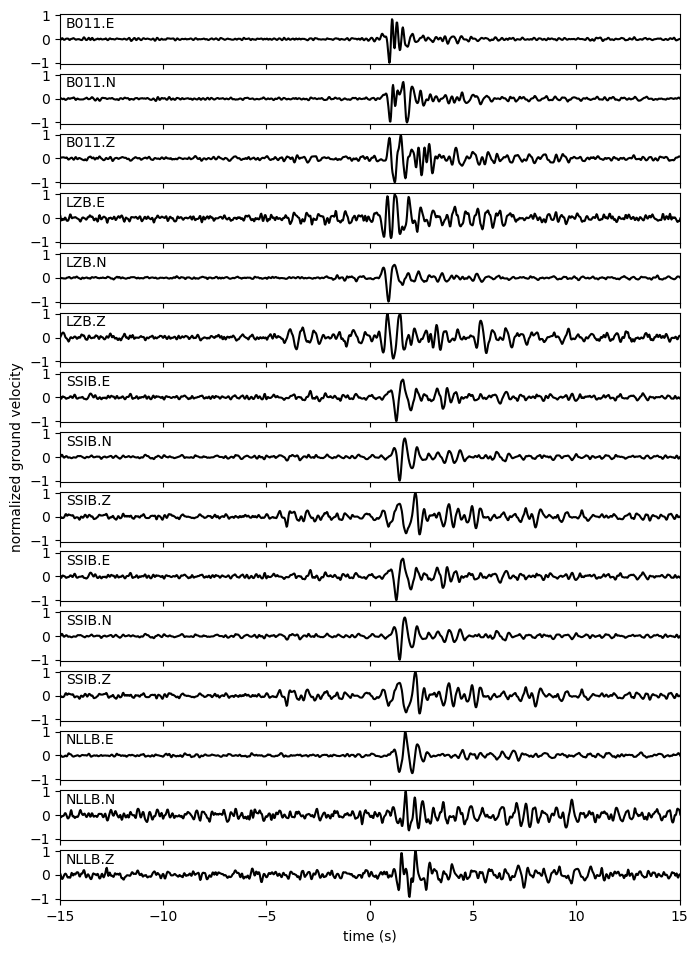

In [6]:
# check that the stacks look okay
lf.plot_stacks(stn=np.random.choice(lf.stns,5))

### 3. What should longer LFEs look like?

So far we've assumed that LFEs all look the same.  But that's not necessarily true.  There might be longer and shorter LFEs in the same place.  The source time function or moment rate function may be 0.3 seconds long in places and 0.6 seconds long in others, as illustrated below.

moment in short stf: 1.01
moment in long stf: 1.00


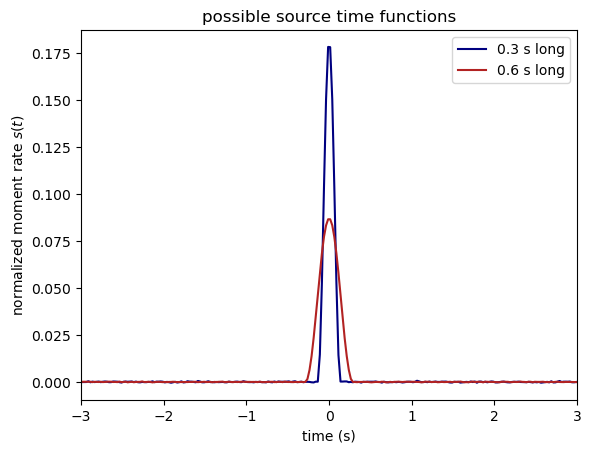

In [7]:
reload(lfeanalysis)
lf=lfeanalysis.lfanalyse(fnum=156,lfi=lf)

# just to create the possible stfs for now
mdata,flt,freq=lf.modify_template(olddur=0.3,newdur=0.6)

# plot these
tm=np.arange(0,lf.old_stf.size)/lf.sampling_rate
tm=tm-np.mean(tm)
nroll=int(lf.old_stf.size/2)
plt.plot(tm,np.roll(lf.old_stf,nroll),color='navy',label='0.3 s long');
plt.plot(tm,np.roll(lf.new_stf,nroll),color='firebrick',label='0.6 s long');
plt.ylabel('normalized moment rate $s(t)$');
plt.xlabel('time (s)');
plt.xlim([-3,3]);
plt.title('possible source time functions');
plt.legend();

print('moment in short stf: {:0.2f}'.format(np.sum(lf.old_stf)))
print('moment in long stf: {:0.2f}'.format(np.sum(lf.new_stf)))

These two moment rate functions have the same total moment, but one is longer than the other.  So we'd observe something different in the seismograms.  Specifically, the observed seismogram $d(t)$ from an LFE is  the convolution of the source time function for that event and the path effect (aka Green's function) $g(t)$ for the source location.

So the observations of a 0.3-s and 0.6-s LFE may look like

$$d_{0.3}(t) = s_{0.3}(t) \ast g(t)$$

$$d_{0.6}(t) = s_{0.6}(t) \ast g(t)$$

Most of the observations we have come from 0.3-s-long LFEs.  So our stacks approximately represent $d_{0.3}(t)$.  We may, however, want to reconstruct $d_{0.6}(t)$.  To do so, we need to deconvolved $s_{0.3}$ from $d_{0.3}$ and then convolve $s_{0.6}$ with the result.

This is easier in the frequency domain, where

$$\hat{d}_{0.3}(f) = \hat{s}_{0.3}(f) \hat{g}(f)$$

$$\hat{d}_{0.6}(f) = \hat{s}_{0.6}(f) \hat{g}(f)$$

So 

$$\hat{d}_{0.6}(f) = \frac{\hat{s}_{0.6}(f)}{\hat{s}_{0.3}(f)} \hat{d}_{0.3}(f)$$

The seismogram of the longer LFE is essentially a filtered version of the seismogram of the shorter LFE. The plots below show the filter $\hat{s}_{0.6}(f)/\hat{s}_{0.3}(f)$ we obtain if we assume that the source time functions are simple peaks like in the figure above.


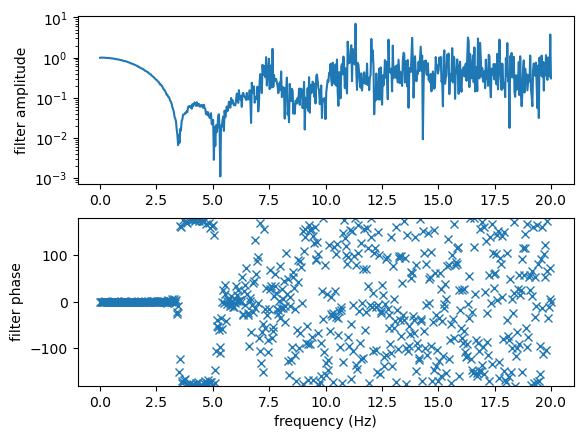

In [8]:
plt.subplot(2,1,1);
plt.plot(freq,np.abs(flt));
plt.ylabel('filter amplitude');
plt.yscale('log');
#plt.xscale('log');

plt.subplot(2,1,2);
plt.plot(freq,np.angle(flt)*180/np.pi,linestyle='none',marker='x');
plt.ylabel('filter phase');
#plt.xscale('log');
plt.xlabel('frequency (Hz)');
plt.ylim([-180,180]);

So let's grab a portion of the stack, convolve with this filter, and see what the seismogram would look like if the LFE were longer.

Note that we're choosing a random station here, and the data may not be available.  If you get an error, try re-running to see if another station is alright.

In [12]:
# grab a stack
tr=lf.totstk.select(channel='E',station=np.random.choice(lf.stns,1)[0])[0]
print(tr)

# and a portion of the data
tr=tr.copy()
tr.trim(starttime=tr.stats.starttime+tr.stats.t0-2,
        endtime=tr.stats.starttime+tr.stats.t0+6)
orig_seis=tr.data
times=tr.times()-2.

# convolve with the relevant filter
new_seis,flt,freq=lf.modify_template(tdata=orig_seis,olddur=0.3,newdur=0.6)

.LZB..E | 1970-01-01T00:00:00.000000Z - 1970-01-01T00:01:19.975000Z | 40.0 Hz, 3200 samples


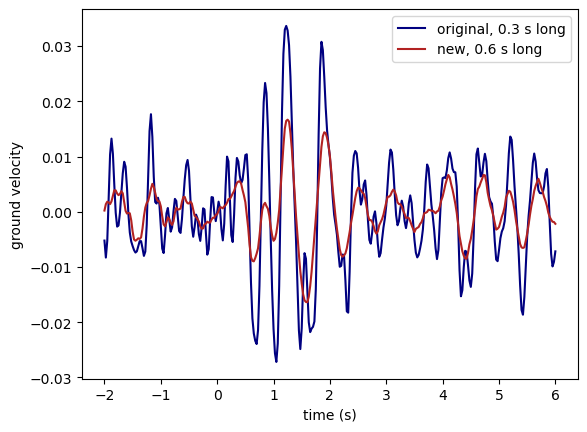

In [13]:
# plot and compare
plt.plot(times,orig_seis,color='navy',label='original, 0.3 s long');
plt.plot(times,new_seis,color='firebrick',label='new, 0.6 s long');
plt.legend();
plt.xlabel('time (s)');
plt.ylabel('ground velocity');

As expected, the longer LFE makes smoother, lower-frequency seismograms.  Sometimes the differences are clear.  Other times they're less obvious though.

### 4. See which stacks look more like the data

We can effectively have two template seismograms: one for what 0.3-s-long LFEs should create and one for what 0.6-s-long LFEs should create.  And of course we can create templates for other durations.

So now let's compare the template for each duration with observations to see which one looks more like the data.

In [14]:
reload(lfeanalysis)
lf=lfeanalysis.lfanalyse(fnum=156,lfi=lf)

# the cross-correlation code has built-in an option to modify the
# stack to reflect a different duration
# this will take the stack, deconvolve a 0.3-s stf, convolve a 0.6-s stf,
# and then compute the cross-correlation with each observation
lf.xc_with_stack(olddur=0.3,newdur=0.6)

# the cross-correlation saves the properties we noted early
# the maximum fully normalized x-c, for instance
xcmax_0p6 = lf.xcmax.copy()

# we might compare these max x-c values
# with the max x-c values we get using an unmodified stack
lf.xc_with_stack(olddur=0.3,newdur=0.3)
xcmax_unmod = lf.xcmax.copy()

And plot the cross-correlations for with the two stacks.

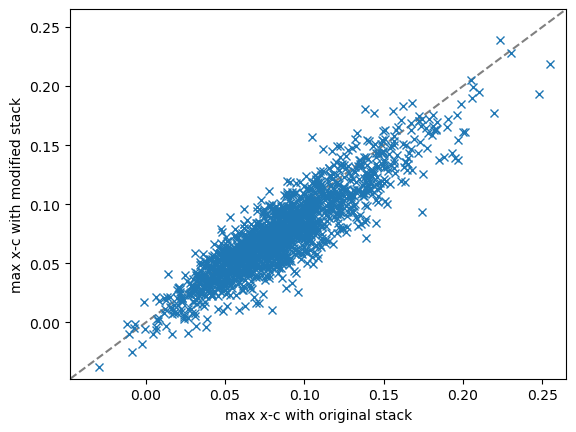

In [15]:
plt.plot(xcmax_unmod,xcmax_0p6,marker='x',linestyle='none')
plt.xlabel('max x-c with original stack');
plt.ylabel('max x-c with modified stack');
xlm=np.append(xcmax_unmod,xcmax_0p6)
xlm=[np.nanmin(xlm)-0.01,np.nanmax(xlm)+0.01]
plt.xlim(xlm);
plt.ylim(xlm);
plt.plot(xlm,xlm,color='gray',linestyle='--',zorder=0);

For most of the points (one per LFE), the cross-correlation with the original stack leads to higher values.  That suggests most of the LFEs have durations close to the average duration.  There are, however, a few points that plot up and to the left of the dashed one-to-one line.  For these events, we may infer that a 0.6-s duration could be a better fit.

### 5. Check a number of durations to find the best match

We now want to run the cross correlations and find the best-fitting value for a number of potential durations.  This search is coded in lf.duration_search.

In [16]:
# we'll only use some of the stations for finding the best durations though
# we want to keep some stations out for unbiased analysis later
lf.split_stations(prc_classify=0.75)

print('Stations used for picking duration: ',lf.cl_stns);

print('\nStations to be used for unbiased analysis later:',lf.an_stns);


Stations used for picking duration:  ['KHVB' 'MGCB' 'PGC' 'SHVB' 'SHDB' 'SHDB']

Stations to be used for unbiased analysis later: ['B926' 'NLLB' 'YOUB' 'LZB']


In [17]:
# try original durations of 0.2 and 0.3 seconds
olddurs=np.array([0.2,0.3])
# and new durations between 0.1 and 0.6 seconds
newdurs=np.arange(0.1,0.61,0.1)
# the maximum allowable time shift will be 0.2 seconds from the specified detection time
lf.duration_search(max_shift=0.2,olddurs=olddurs,newdurs=newdurs)

Old duration 0.2 New duration 0.2
Old duration 0.2 New duration 0.30000000000000004
Old duration 0.2 New duration 0.4
Old duration 0.2 New duration 0.5
Old duration 0.2 New duration 0.6
Old duration 0.3 New duration 0.30000000000000004
Old duration 0.3 New duration 0.4
Old duration 0.3 New duration 0.5
Old duration 0.3 New duration 0.6


After the search, we can check out the cross-correlation values, obtained from the _classification_ stations.

Best xc: (1658,) [0.02720881 0.05561764 0.05698092 ... 0.10997241 0.03454895 0.09836547]
Best original durations: (1658,) [0.3 0.3 0.2 ... 0.2 0.2 0.2]
Best new durations: (1658,) [0.3 0.5 0.6 ... 0.2 0.4 0.6]


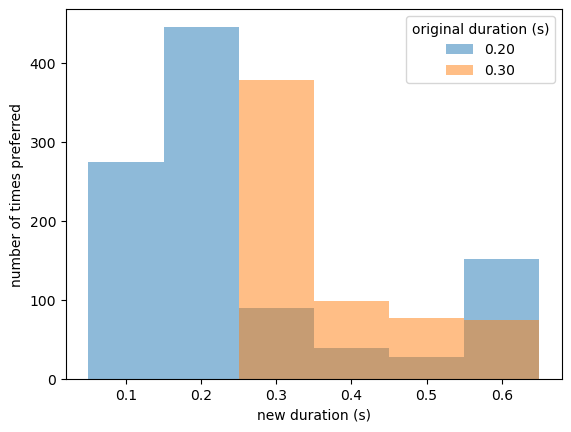

In [18]:
# we now have the highest cross-correlation values
print('Best xc:',lf.xc_best.shape,lf.xc_best)

# we have a list of the "original" durations that give these values
print('Best original durations:',lf.olddur.shape,lf.olddur)

# we have a list of the "new" durations that give these values
print('Best new durations:',lf.newdur.shape,lf.newdur)

# for Cascadia, most of the best-fitting durations are similar to the original duration
bns=(lf.newdurs[0:-1]+lf.newdurs[1:])/2.
bns=np.append(bns[0]-(bns[1]-bns[0]),bns)
bns=np.append(bns,bns[-1]+(bns[1]-bns[0]))
for k in range(0,lf.olddurs.size):
    ii=lf.olddur==lf.olddurs[k]
    plt.hist(lf.newdur[ii],bins=bns,alpha=0.5,label='{:0.2f}'.format(lf.olddurs[k]));
plt.legend(title='original duration (s)');
plt.xlabel('new duration (s)');
plt.ylabel('number of times preferred');

We also now have computed the relevant LFE amplitudes, per station and LFE. These amplitudes use the best-fitting durations obtained with the _classification_ stations, but the amplitudes are obtained for the _analysis_ stations.

In [19]:
# we also have amplitudes estimated for each LFE and *analysis* station
# here we collect the values from the best-fitting durations
print('\nAmplitude by station and LFE:',lf.allamps_bdur.shape,np.nanmedian(lf.allamps_bdur));



Amplitude by station and LFE: (1658, 4) 1.1085005099221189e-07


Finally, we have a station amplitude for each of the analysis station and relative moments for each of the LFEs.

In [20]:
# the station corrections
print('Station amplitudes :',lf.statamp_bdur.shape,lf.statamp_bdur)

# the relative LFE moments
print('\nLFE moments :',lf.evamp_bdur.shape,lf.evamp_bdur[~np.isnan(lf.evamp_bdur)])

Station amplitudes : (4,) [9.08736115e-08 9.38748670e-08 1.38743630e-07 1.51672392e-07]

LFE moments : (1658,) [ 3.05640502e-01  4.73200568e-01  9.27954510e-01  1.43423662e+00
  8.11809133e-01  6.69344132e-01  8.89658568e-01  1.71110437e+00
  1.64603795e+00  1.70497999e+00  2.55549663e-01  1.23151244e+00
  1.61936829e+00  1.32792481e+00  6.57926987e-01  1.31703332e+00
  5.39224564e-01  3.93306518e-01  8.02539744e-01  4.77332515e-01
  1.01939086e+00  5.50419495e-01  3.34603862e+00  2.74257690e+03
  1.32643874e+00  3.51964836e+00  2.06237825e+00  2.93964368e+00
  4.41871338e+00  1.03194206e+00  1.27294324e+00  1.56141158e+00
  9.36204844e-01  8.81259464e-01  1.06862965e+00  2.51270748e+00
  1.91758999e+00  9.24410998e-01  8.71146675e-01  3.60202094e+00
  1.39345492e+00  1.23730835e+00  1.92357858e+00  2.06553294e+00
  9.93223422e-01  2.51060913e+00  1.63495853e+00  1.98226505e+00
  1.58214618e+00  2.02169337e+00  1.35852921e+00  6.63633817e-01
  1.81221112e+00  1.76753259e+00  1.25699480

### 6. Compare the LFE moments and durations

Finally, we can compare the LFEs moments to their durations.

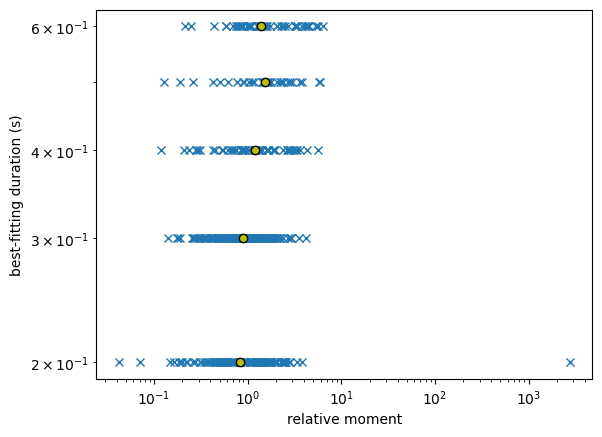

In [21]:
# compute the median amplitude per duration
medmom=np.zeros(lf.newdurs.size,dtype=float)*float('nan')
for k in range(0,lf.newdurs.size):
    ii=np.logical_and(lf.newdur==lf.newdurs[k],~np.isnan(lf.evamp_bdur))
    if np.sum(ii):
        medmom[k]=np.median(lf.evamp_bdur[ii])

plt.plot(lf.evamp_bdur,lf.newdur,marker='x',linestyle='none');
plt.plot(medmom,lf.newdurs,marker='o',linestyle='none',markerfacecolor='y',color='k');
plt.xlabel('relative moment');
plt.ylabel('best-fitting duration (s)');
plt.xscale('log');
plt.yscale('log');

For Michael Bostock's catalogue in Cascadia, there's no apparent relationship between moment and duration.